In [1]:
from Stellarator2 import StellaratorTransport

from Objective2 import make_objective

import matplotlib.pyplot as plt
from desc.profiles import SplineProfile
from desc.plotting import plot_boozer_surface, plot_boundaries, plot_qs_error
from desc.plotting import plot_comparison
from desc.plotting import plot_1d
from desc.objectives import (
    AspectRatio,
    FixBoundaryR,
    FixBoundaryZ,
    FixCurrent,
    FixPsi,
    ForceBalance,
    LinearObjectiveFromUser,
    ObjectiveFunction,
    ObjectiveFromUser,
    QuasisymmetryTwoTerm,
    RotationalTransform,
    Volume,
)
from desc.grid import Grid, LinearGrid
from desc.geometry import FourierRZToroidalSurface
from desc.equilibrium import Equilibrium, EquilibriaFamily
import desc.io
import desc
from yancc_wrapper2 import yancc_data
import yancc
import jax.numpy as jnp
import numpy as np
import jax

import MaNTA


Registering cpu implementation for operation get_solution
Registering gpu implementation for operation get_solution
Registering cpu implementation for operation get_adjoint_gradients
Registering gpu implementation for operation get_adjoint_gradients
Registering cpu implementation for operation get_g_val
Registering cpu implementation for operation run
Registering cpu implementation for operation run_ss
Using cache directory: /global/cfs/cdirs/mp217/eatocco/__pycache__
[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:

fname = "stellarator_opt"

eq_name = "eq6"

st_config = {
    "SourceCenter": 0.2,
    "SourceHeight": 40.0,
    "SourceWidth": 0.1,
    "EdgeTemperature": 0.2,
    "EdgeDensity": 0.2,
    "n0": 0.5,
    "use_chunking": True,
}

rho_upper = 1.0
rtol = 1e-2
atol = 1e-3
# nodes = [0.0,0.5, 0.75, 0.9, 1.0]
npoints = 8
degree = 4
base = 1.4
tau = 1.0
start_point = 0.6

n1 = jnp.linspace(start_point, 1.0, npoints-1)
nodes = np.concatenate(([0.0, 0.4], n1))

# a = start_point  # Start of interval
# b = 1.0  # End of interval
# n = npoints + 3  # Number of nodes

# k = np.arange(1, n + 1)
# std_nodes = np.cos((2 * k - 1) / (2 * n) * np.pi)
# std_nodes = std_nodes[2:-2]
# # Shift and scale to [a, b]
# scaled_nodes = 0.5 * (a + b) + 0.5 * (b - a) * std_nodes
# nodes = np.concatenate(([0, 0.5, start_point], scaled_nodes[::-1], [1]))

# # %%
solver_config = {
    "OutputFilename": "stellarator_opt0",
    "Polynomial_degree": degree,
    "Grid_points": nodes,
    "tau": tau,
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-3,
    "initialTimestep": 1e-5,
    "MinStepSize": 1e-9,
    "SteadyStateTolerance": 1e-4,
    "restart": False,
    "zeroFlux": True,
    "optimizeMode": True, 
}


config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}


points = MaNTA.getNodes(
    nodes,
    solver_config["Polynomial_degree"],
)


yancc_rho = jnp.array(points)
yancc_ntheta = 17
yancc_nzeta = 33

yancc_res = {"na": 45, "nx": 5}
# to allow maximum flexibility to match manta, we use a spline with the same control p]boints as manta \
# + axis and lcfs
# initial pressure is all zeros, can change this if desired

pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)

# eq = desc.examples.get("precise_QA")
eq = desc.io.load(eq_name + ".h5")
# surf = eq.get_surface_at(rho=1)
# eq = Equilibrium(M=4, N=4, Psi = 0.1, surface=surf, pressure = desc_pressure)
eq = eq.solve(x_scale="ess")[0]
# surf = FourierRZToroidalSurface.from_qp_model(
#     major_radius=1,
#     aspect_ratio=8,
#     elongation=3,
#     mirror_ratio=0.2,
#     torsion=0.1,
#     NFP=4,
#     sym=True,
# )
# # surf = FourierRZToroidalSurface(
# #     R_lmn=[1, 0.125, 0.1],
# #     Z_lmn=[-0.125, -0.1],
# #     modes_R=[[0, 0], [1, 0], [0, 1]],
# #     modes_Z=[[-1, 0], [0, -1]],
# #     NFP=4,
# # )
# # # create initial equilibrium. Psi chosen to give B ~ 1 T. Could also give profiles here,
# # # default is zero pressure and zero current
# eq = Equilibrium(M=4, N=4, Psi=0.1, surface=surf, pressure=desc_pressure)
# eq = eq.solve(x_scale="ess")[0]
# # this is usually all you need to solve a fixed boundary equilibrium
# 
# # print(pressure_rho)
# eqs = EquilibriaFamily(eq)
# eq = desc.io.load("eq_self_consistent_pressure.h5")
# desc_pressure = eq.get_profile('p')
eq_init = eq.copy()

V0 = eq.compute("V")["V"]
# yancc_wrapper = yancc_data.from_eq(points, grid = yancc_grid,rho = yancc_rho, Density=Density, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_wrapper = yancc_data.from_eq(
    points, eq=eq_init, nt=yancc_ntheta, nz=yancc_nzeta, **yancc_res
)
## %%
#
#

# plt.plot(points, 2.0 / 3.0 * st.InitialValue(0, points) / yancc_wrapper.Vp)


Building objective: force
Precomputing transforms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Number of parameters: 120
Number of objectives: 850

Starting optimization
Using method: lsq-exact
Optimization terminated successfully.
`ftol` condition satisfied. (ftol=1.00e-02)
         Current function value: 7.774e-03
         Total delta_x: 6.420e-03
         Iterations: 1
         Function evaluations: 2
         Jacobian evaluations: 2
                                                                 Start  -->   End
Total (sum of squares):                                      7.775e-03  -->   7.774e-03, 
Maximum absolute Force error:          

In [3]:

st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
st.run()


configuring
Successfully created StellaratorTransport object


ERROR: Residual norm at t = 0: inf
ERROR: Residual norm at t = 0: -nan
ERROR: Residual norm at t = 0: 1.3356683675383998
ERROR: Residual norm at t = 1e-05: -nan
ERROR: Residual norm at t = 1e-05: 8.554925197594704
ERROR: Residual norm at t = 3.2783018111756347e-06: 0.34827233621541726
ERROR: Residual norm at t = 3.2783018111756347e-06: 4.052567987681822
ERROR: Residual norm at t = 8.195754527939087e-07: 0.05615475618743422
ERROR: Residual norm at t = 8.195754527939087e-07: 1.6355082018963023
ERROR: Residual norm at t = 1.4902898931833704e-06: 0.007536502199381468
ERROR: Residual norm at t = 1.4902898931833704e-06: 0.595386512729597
ERROR: Residual norm at t = 2.161004333572832e-06: 0.030664702194718108
ERROR: Residual norm at t = 3.502433214351755e-06: 0.2527238183517368
ERROR: Residual norm at t = 3.502433214351755e-06: 0.39662382789846534
ERROR: Residual norm at t = 4.843862095130678e-06: 0.032657888698679506
ERROR: Residual norm at t = 7.5267198566885255e-06: 0.26182194330458264
ERR

INFO: Creating grid with cell boundaries at x = [0, 0.4, 0.6, 0.6666666666666666, 0.7333333333333334, 0.8, 0.8666666666666667, 0.9333333333333333, 1]
INFO: Using default value false for parameter solveAdjoint
INFO: Total HDG degrees of freedom 129
INFO: Using default value 0 for parameter tZero
INFO: Using default value 301 for parameter OutputPoints
INFO: Using default value true for parameter WriteOutput
INFO: Using default value false for parameter aggressiveTimesteps
INFO: Configuration done
INFO: Setting initial conditions
INFO: Number of Residual Evaluations due to IDACalcIC: 3
Writing output at 0.001 ( 35 timesteps )


ERROR: Residual norm at t = 0.001206764139273046: 0.0005311505015943477
ERROR: Residual norm at t = 0.001378467036012748: 0.4474962345741845
ERROR: Residual norm at t = 0.0015501699327524503: 0.3328462788415421
ERROR: Residual norm at t = 0.0018935757262318546: 0.23799879756101103
ERROR: Residual norm at t = 0.0018935757262318546: 0.41445479972895805
ERROR: Residual norm at t = 0.002236981519711259: 0.05609359398434975
ERROR: Residual norm at t = 0.002236981519711259: 0.8143912116665238


Writing output at 0.002 ( 40 timesteps )


ERROR: Residual norm at t = 0.0025803873131906635: 0.0008552541526996168
ERROR: Residual norm at t = 0.0025803873131906635: 0.2512794038554238
ERROR: Residual norm at t = 0.002923793106670068: 0.018395868369791315
ERROR: Residual norm at t = 0.0036106046936288765: 0.06873716504536213
ERROR: Residual norm at t = 0.0036106046936288765: 0.1797824918191254


Writing output at 0.003 ( 43 timesteps )
Steady State achieved at time t = 0.003
Total Number of Timesteps             :43
Total Number of Residual Evaluations  :66
Total Number of Jacobian Computations :12
Done.


Initializing yancc wrapper
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=45, nx=5.
configuring
Successfully created StellaratorTransport object


ERROR: Residual norm at t = 0: inf
ERROR: Residual norm at t = 0: 0
ERROR: Residual norm at t = 0: 0.08003419943094642
ERROR: Residual norm at t = 1e-06: -nan
ERROR: Residual norm at t = 2e-06: 0.0006379753663264633
ERROR: Residual norm at t = 4e-06: 2.0642395940716838e-05
ERROR: Residual norm at t = 8e-06: 5.4293248907312543e-05
ERROR: Residual norm at t = 1.6e-05: 4.185399172018795e-05
ERROR: Residual norm at t = 3.2e-05: 3.95760740508032e-05
ERROR: Residual norm at t = 6.4e-05: 0.00014180468201480578
ERROR: Residual norm at t = 0.000128: 0.0005380328777112777
ERROR: Residual norm at t = 0.000256: 0.0019767535725860813
ERROR: Residual norm at t = 0.000512: 0.006853297958647141
ERROR: Residual norm at t = 0.000512: 0.021703298202581014
ERROR: Residual norm at t = 0.001024: 8.038864242142598e-06
ERROR: Residual norm at t = 0.001024: 0.06049988253940271


INFO: Using default value false for parameter solveAdjoint
INFO: Total HDG degrees of freedom 129
INFO: Using default value 0 for parameter tZero
INFO: Using default value 301 for parameter OutputPoints
INFO: Using default value true for parameter WriteOutput
INFO: Using default value false for parameter aggressiveTimesteps
INFO: Using default value false for parameter optimizeMode
INFO: Configuration done
INFO: Setting initial conditions
INFO: Number of Residual Evaluations due to IDACalcIC: 3
Writing output at 0.001 ( 11 timesteps )
Steady State achieved at time t = 0.001
Total Number of Timesteps             :11
Total Number of Residual Evaluations  :16
Total Number of Jacobian Computations :11
Done.
[1593.54562246 1708.65742081 1677.30339904 1645.52510805 1588.61834501
 1607.11894235 1525.65197848 1482.84388221 1370.86120257 1342.50401028
 1316.34727066 1297.75838783 1267.10792423 1237.09825162 1218.30326358
 1213.49329925 1195.0249348  1165.43252229 1135.9332733  1117.80257647
 11

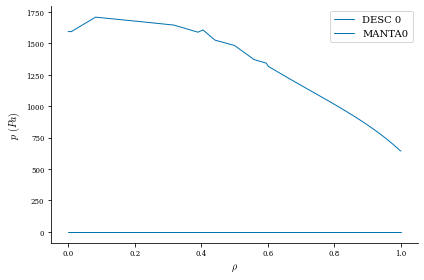

In [4]:

solver_config = {
    "OutputFilename": fname,
    "RestartFile": "stellarator_opt0.restart.nc",
    "Polynomial_degree": degree,
    "Grid_points": nodes, 
    "tau": tau,
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-3,
    "initialTimestep": 1e-6,
    "MinStepSize": 1e-10,
    "restart": True,
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-4,
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

pi = []
fig, ax = plt.subplots()
eq2 = eq.copy()
fam2 = EquilibriaFamily(eq2)
niters = 1
for k in range(niters):
    eq2 = eq2.copy()

    fig, ax = plot_1d(eq2, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(
        points, eq=eq2, nt=yancc_ntheta, nz=yancc_nzeta, **yancc_res
    )
    pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()

    pi = st.getPressure()

    print(pi)
    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.array([pi[-1]])])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq2.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq2, _ = eq2.solve(objective="force", optimizer="lsq-exact", verbose=3)
    fam2.append(eq2)
eq_self_consistent = eq2.copy()

ax.legend()
fig.savefig("initial_self_consistent_pressure.png")

(<Figure size 864x720 with 6 Axes>,
 array([<Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.000$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.167$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.333$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.500$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.667$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.833$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>],
       dtype=object))

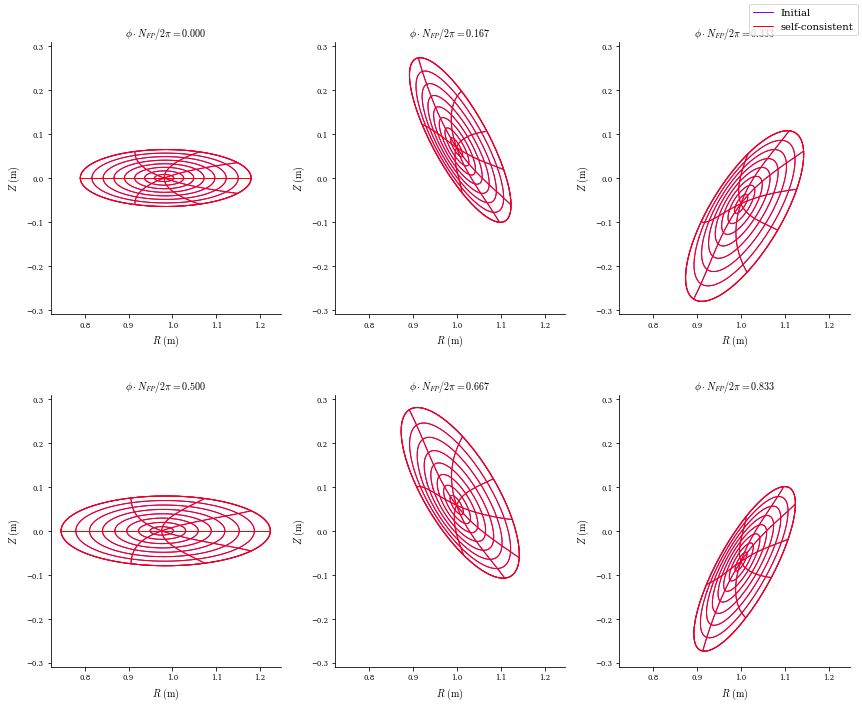

In [5]:
#eq2.save(eq_name+"_init_sc.h5")
plot_comparison(eqs=[eq_init, eq2], labels=["Initial", "self-consistent"])


In [6]:
eq = eq2.copy()



In [3]:

# %%
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": degree,
    "Grid_points": nodes, 
    "tau": tau * 1000.0,
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 0.01,
    "initialTimestep": 1e-6,
    "MinStepSize": 1e-10,
    "restart": True,
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-3,
    "optimizeMode": True,
}
config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}


manta_objective = make_objective(config, yancc_res=yancc_res)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime)

#     return stored_energy, pressure


def objective_from_user_fun(grid, data):
    # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data["V(r)"])
    V_r = grid.compress(data["V_r(r)"])
    V_rr = grid.compress(data["V_rr(r)"])
    Vp = V_r / V[-1]
    Vpp = V_rr / V[-1]

    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")

    stored_energy, manta_pressure = manta_objective((fields, Vp, Vpp), grid)
    stored_energy_unnorm = stored_energy * V[-1]/V0
    print("------------ STORED ENERGY ----------------")
    print(stored_energy)
    print("-------------------------------------------")

    # not sure if the sign makes the difference here
    pressure_error = manta_pressure - desc_pressure

    print("------------TOTAL PRESSURE ERROR-----------")
    print(pressure_error)
    print("-------------------------------------------")

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return 1 / stored_energy_unnorm  # jnp.append(pressure_error, 1 / stored_energy)


yancc_desc_grid = yancc_wrapper.grid

# domain_boundary_rho = rho_from_normalized_volume(0.9)
domain_boundary_rho = 1.0


def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(
        Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l
    )
    return jnp.array([dp0, p1]).squeeze()


pi_edge = (
    st_config["EdgeTemperature"]
    * st_config["EdgeDensity"]
    * yancc_wrapper.nNorm
    * yancc_wrapper.Tnorm
    * 1.6e-19
)
pressure_constraint_target = jnp.array([0.0, pi_edge])


# pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])


In [16]:

def fun_mirror_ratio(grid, data):
    # alternatively, "mirror ratio" is something that can be computed in the data index
    # directly (see List of Variables docs), so can replace entirety of the above function code with this return statement
    return grid.compress(data["mirror ratio"])
    # or can just use GenericObjective(f="mirror ratio", thing=eq) or the already-existing objective, MirrorRatio(eq)


obj_mirror_ratio = ObjectiveFromUser(
    fun=fun_mirror_ratio,
    thing=eq,
    grid=yancc_desc_grid,
    bounds=(0.0, 0.25),
    weight=2.0,
    name="my mirror ratio",
)




# pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])

# %%

# other objectives are non-dimensionalized, so weights should account for that
# and handle relative weighting, this will likely need trial and error
# pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1e-5)

# pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 2e-6)
stored_energy_weight = 10.0
# jnp.append(stored_energy_weight)
objective_from_user_weight = stored_energy_weight
max_it = 5

eqfam = EquilibriaFamily(eq)
# ks = [1, 2, eq.M + 1]
# for k in ks:
# print("\n==================================")
# print("Optimizing boundary modes M,N <= {}".format(k))
# print("====================================")
#
grid = LinearGrid(
    M=eq.M_grid, N=eq.N_grid, NFP=eq.NFP, rho=np.array([0.6, 0.8, 1.0]), sym=True
)

transport_objective = ObjectiveFromUser(
        objective_from_user_fun,
        eq,
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd",
        # need this assuming manta only has vjp, if using jvp switch to fwd
    )
transport_objective.build(use_jit=False)

objectives = [
    # AspectRatio(eq=eq, target=6, weight=10),
    obj_mirror_ratio,
    Volume(eq=eq, target=V0, weight=10.0),
    QuasisymmetryTwoTerm(eq=eq, helicity=(1, eq.NFP), grid=grid),
    # try to keep the aspect ratio about the same
    AspectRatio(eq=eq, target=8, weight=100),
    # RotationalTransform(eq=eq, target=0.42, weight=10),
    transport_objective
]

objective = ObjectiveFunction(objectives)
k = 4

R_modes = np.vstack(
    (
        [0, 0, 0],
        eq.surface.R_basis.modes[
            np.max(np.abs(eq.surface.R_basis.modes), 1) > k
            , :
        ],
    )
)
Z_modes = eq.surface.Z_basis.modes[
    np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :
]
constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    # fix zero current, eventually should use real bootstrap
    FixCurrent(eq=eq),
    FixBoundaryR(eq=eqfam[-1], modes=R_modes),
    FixBoundaryZ(eq=eqfam[-1], modes=Z_modes),
    FixPsi(eq=eq),  # fix total magnetic flux
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]
# print(objective.jac_scaled(objective.x(eq)))
eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-fmintr-bfgs",
    x_scale="ess",
    maxiter=max_it,
    ftol=1e-6,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    # options={
    #     "initial_trust_radius": 10.0,
    #     # "perturb_options": {"order": 2, "verbose": 3},  # use 2nd-order perturbations
    #     #     # "solve_options": {
    #     #     #     "ftol": 5e-3,
    #     #     #     "xtol": 1e-6,
    #     #     #     "gtol": 1e-6,
    #     #     #     "verbose": 3,
    #     # },  # for equilibrium subproblem
    # },
    verbose=3,
    copy=True,
)



Flux norm : JitTracer(~float64[])
yancc_wrapper initialized successfully with resolution na=45, nx=5.
configuring
Successfully created StellaratorTransport object
------------ STORED ENERGY ----------------
JitTracer(float32[1])
-------------------------------------------
------------TOTAL PRESSURE ERROR-----------
JitTracer(float64[40])
-------------------------------------------


/global/cfs/cdirs/mp217/eatocco/DESC/desc/utils.py:563: UserWarning: At least 1 sub-objective has use_jit=False. Setting use_jit=False for the whole ObjectiveFunction. Sub-objectives with use_jit=False: ['ObjectiveFromUser']
  warnings.warn(msg, err)


Building objective: my mirror ratio
Building objective: volume
Precomputing transforms
Timer: Precomputing transforms = 559 ms
Building objective: QS two-term
Precomputing transforms
Timer: Precomputing transforms = 99.2 ms
Building objective: aspect ratio
Precomputing transforms
Timer: Precomputing transforms = 41.0 ms
Timer: Objective build = 1.57 sec
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 859 ms
Timer: Objective build = 903 ms
Timer: Objective build = 1.84 ms
Timer: Eq Update LinearConstraintProjection build = 422 ms
Timer: Proximal projection build = 6.85 sec
Building objective: fixed current
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: custom linear
Timer: Objective build = 3.68 sec
Timer: LinearConstraintProjection build = 7.22 sec
Number of parameters: 120
Number of objectives: 502
Timer: Initializing the optimization = 18.0 sec

Starting optimization
Using method: proximal-fmi

ERROR: Residual norm at t = 0: inf
ERROR: Residual norm at t = 0: 0
ERROR: Residual norm at t = 0: 0.05794507982292932
ERROR: Residual norm at t = 1e-06: 0
ERROR: Residual norm at t = 1e-06: 0.023554053348163767
ERROR: Residual norm at t = 2e-06: 0.0003452693995058536
ERROR: Residual norm at t = 4e-06: 0.005281277084492785
ERROR: Residual norm at t = 4e-06: 0.006975623127519839
ERROR: Residual norm at t = 8e-06: 0.00047774431546466014
ERROR: Residual norm at t = 8e-06: 0.049628967808841774
ERROR: Residual norm at t = 3.270814985492066e-05: 2.1486134556242924e-06
ERROR: Residual norm at t = 3.270814985492066e-05: 0.8796195694966533
ERROR: Residual norm at t = 3.0237334869428596e-05: 7.848332117800615e-05
ERROR: Residual norm at t = 3.0237334869428596e-05: 0.11845793971949813
ERROR: Residual norm at t = 8.131776235688489e-05: 0.007296321663414415
ERROR: Residual norm at t = 8.131776235688489e-05: 0.0742572582810225
ERROR: Residual norm at t = 0.00024001850698847295: 4.016955715308807e-06

INFO: Using default value  for parameter RestartFile
INFO: Using default value false for parameter solveAdjoint
INFO: Total HDG degrees of freedom 129
INFO: Using default value 0 for parameter tZero
INFO: Using default value 301 for parameter OutputPoints
INFO: Using default value true for parameter WriteOutput
INFO: Using default value false for parameter aggressiveTimesteps
INFO: Configuration done
INFO: Setting initial conditions
INFO: Initial dGdt = 1.3153990433782565
INFO: Number of Residual Evaluations due to IDACalcIC: 3
INFO: Using default value  for parameter RestartFile
INFO: Using default value false for parameter solveAdjoint
INFO: Total HDG degrees of freedom 129
INFO: Using default value 0 for parameter tZero
INFO: Using default value 301 for parameter OutputPoints
INFO: Using default value true for parameter WriteOutput
INFO: Using default value false for parameter aggressiveTimesteps
INFO: Configuration done
INFO: Using default value  for parameter RestartFile
INFO: Usi

...

Writing output at 0.02 ( 24 timesteps )


ERROR: Residual norm at t = 0.042438540069526146: 0.15286304021529473
ERROR: Residual norm at t = 0.042438540069526146: 0.4646731268304924


Writing output at 0.03 ( 25 timesteps )
Writing output at 0.04 ( 25 timesteps )


ERROR: Residual norm at t = 0.05873135848377607: 0.00046802980389501925


Writing output at 0.05 ( 26 timesteps )
Steady State achieved at time t = 0.05
Total Number of Timesteps             :26
Total Number of Residual Evaluations  :47
Total Number of Jacobian Computations :13
Done.
                                                                 Start  -->   End
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=45, nx=5.
configuring
Successfully created StellaratorTransport object
------------ STORED ENERGY ----------------
[0.520424]
-------------------------------------------
------------TOTAL PRESSURE ERROR-----------
[7969.67075181 7863.88816918 7868.35730363 7800.02514244 7679.89272063
 7605.85483567 7512.7376833  7133.87971416 6637.49635676 6205.62901127
 6142.40867676 5988.17663794 5724.5796108  5446.23519758 5268.69899632
 5220.00307639 5036.43347567 4729.4553988  4415.53274472 4220.08573853
 4167.28407972 3971.25110354 3654.8466855  3341.31800825 3146.27046668
 3098.76226753 2905.5247807  2597.97901553 2294.84

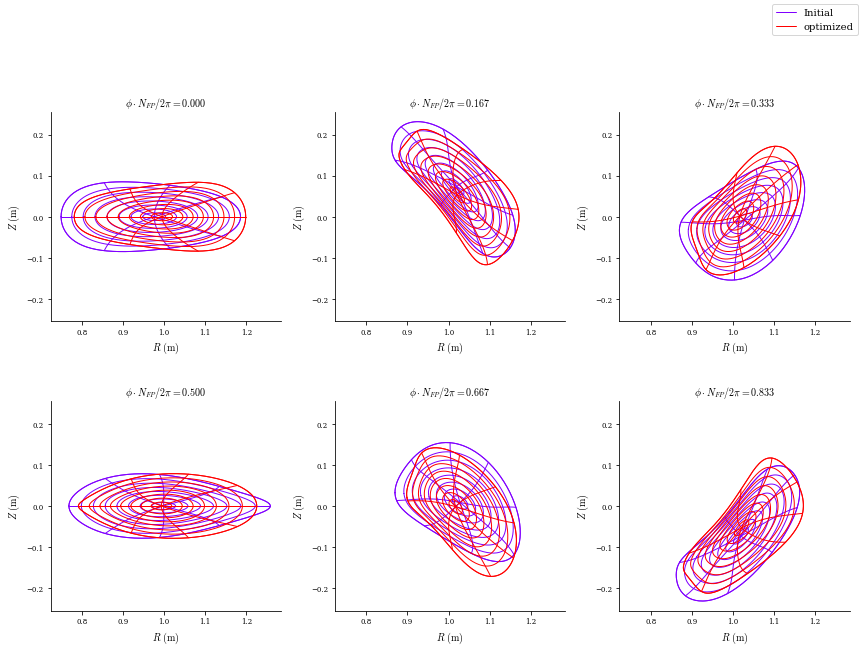

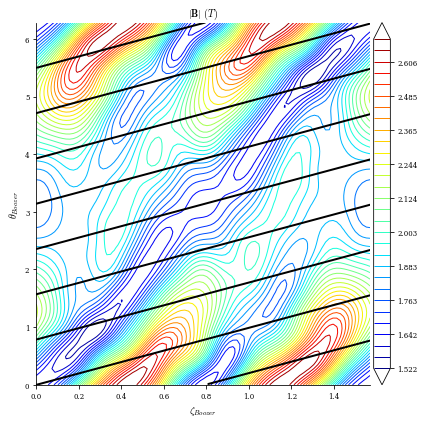

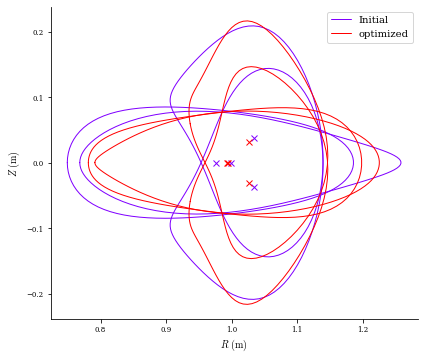

In [17]:

eqfam.append(eq.copy())
fig, ax = plot_comparison(eqs=[eq_init, eq], labels=["Initial", "optimized"])
fig.savefig("figs/" + eq_name + "comparison")
fig, ax = plot_boozer_surface(eq, fieldlines=8)
fig, ax = plot_boundaries(
    eqs=[eq_init, eq], labels=["Initial", "optimized"]
)

eq.save(eq_name + ".h5")


Initializing yancc wrapper
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=45, nx=5.
configuring
Successfully created StellaratorTransport object


ERROR: Residual norm at t = 0: -nan
ERROR: Residual norm at t = 0: -nan
ERROR: Residual norm at t = 0: 2.2638798095151413
ERROR: Residual norm at t = 1e-06: -nan
ERROR: Residual norm at t = 1e-06: 0.5997300458456556
ERROR: Residual norm at t = 2e-06: 0.001741992583567957
ERROR: Residual norm at t = 4e-06: 0.2500053401359097
ERROR: Residual norm at t = 4e-06: 0.547961445344734
ERROR: Residual norm at t = 6e-06: 0.02694064481521486
ERROR: Residual norm at t = 6e-06: 0.2576687295448209
ERROR: Residual norm at t = 8e-06: 0.0003756988411615463
ERROR: Residual norm at t = 1.2e-05: 0.05717580503961563
ERROR: Residual norm at t = 1.2e-05: 0.13133218989842912
ERROR: Residual norm at t = 1.9999999999999998e-05: 8.602762780994273e-05
ERROR: Residual norm at t = 1.9999999999999998e-05: 0.27055375757906364
ERROR: Residual norm at t = 2.7999999999999996e-05: 0.00011450482947600473
ERROR: Residual norm at t = 4.4e-05: 0.17197428167564227
ERROR: Residual norm at t = 4.4e-05: 0.41276263414476666
ERROR:

INFO: Using default value  for parameter RestartFile
INFO: Using default value false for parameter solveAdjoint
INFO: Total HDG degrees of freedom 129
INFO: Using default value 0 for parameter tZero
INFO: Using default value 301 for parameter OutputPoints
INFO: Using default value true for parameter WriteOutput
INFO: Using default value false for parameter aggressiveTimesteps
INFO: Configuration done
INFO: Setting initial conditions
INFO: Using default value  for parameter RestartFile
INFO: Using default value false for parameter solveAdjoint
INFO: Total HDG degrees of freedom 129
INFO: Using default value 0 for parameter tZero
INFO: Using default value 301 for parameter OutputPoints
INFO: Using default value true for parameter WriteOutput
INFO: Using default value false for parameter aggressiveTimesteps
INFO: Configuration done
INFO: Setting initial conditions
INFO: Number of Residual Evaluations due to IDACalcIC: 3
Writing output at 0.01 ( 38 timesteps )


ERROR: Residual norm at t = 0.013083359999999999: 0.007015841050610712
ERROR: Residual norm at t = 0.014742239999999998: 0.6867927670047216
ERROR: Residual norm at t = 0.016401119999999998: 0.38624053062799935
ERROR: Residual norm at t = 0.019718879999999998: 0.34823286148152643
ERROR: Residual norm at t = 0.019718879999999998: 0.6770830663034706
ERROR: Residual norm at t = 0.023036639999999997: 0.08718374950048291


Writing output at 0.02 ( 43 timesteps )


...

Writing output at 0.03 ( 46 timesteps )


ERROR: Residual norm at t = 0.03630768: 0.14725331827608285
ERROR: Residual norm at t = 0.0429432: 0.391107810900655
ERROR: Residual norm at t = 0.0429432: 1.2292854654925816


Writing output at 0.04 ( 48 timesteps )


ERROR: Residual norm at t = 0.04957872: 0.001698764707267187
ERROR: Residual norm at t = 0.04957872: 0.6719068798799765
ERROR: Residual norm at t = 0.05621424: 0.028236167855674083


Writing output at 0.05 ( 50 timesteps )
Steady State achieved at time t = 0.05
Total Number of Timesteps             :50
Total Number of Residual Evaluations  :73
Total Number of Jacobian Computations :13
Done.
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 101 ms
Timer: Objective build = 775 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 690 ms
Timer: LinearConstraintProjection build = 1.01 sec
Number of parameters: 120
Number of objectives: 850
Timer: Initializing the optimization = 2.48 sec

Starting optimization
Using method: lsq-exact
Solver options:
-----------------------------

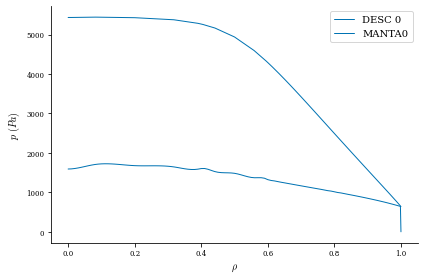

In [13]:


eq_sc = eq.copy()
# final self consistency
niters = 1
fig, ax = plt.subplots()
for k in range(niters):
    fig, ax = plot_1d(eq_sc, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(
        points, eq=eq_sc, nt=yancc_ntheta, nz=yancc_nzeta, **yancc_res
    )

    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()

    pi = st.getPressure()

    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq_sc.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0

    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq_sc, _ = eq_sc.solve(
        objective="force", x_scale="ess", optimizer="lsq-exact", verbose=3
    )

eqfam.append(eq_sc)
ax.legend()
fig.savefig("figs/" + eq_name + "final_pressure_comparison.png")
eqfam.save(eq_name + "_all_equilibria.h5")

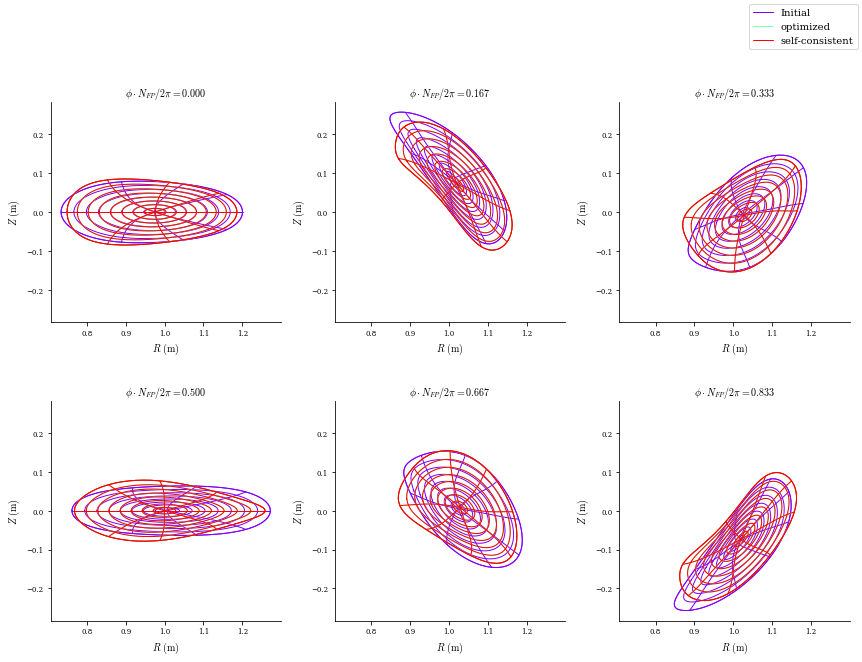

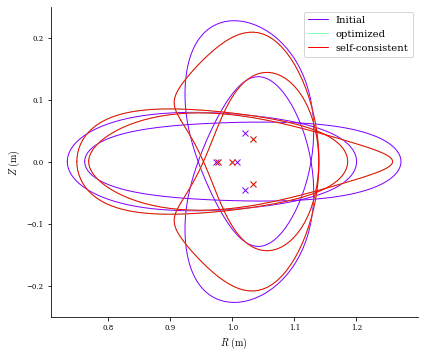

In [13]:

fig, ax = plot_comparison(
    eqs=[eq_init, eq, eq_sc], labels=["Initial", "optimized", "self-consistent"]
)
fig.savefig("figs/" + eq_name + "final_comparison.png")
fig, ax = plot_boundaries(
    eqs=[eq_init, eq, eq_sc], labels=["Initial", "optimized", "self-consistent"]
)
fig.savefig("figs/" + eq_name + "final_comparison_boundary.png")

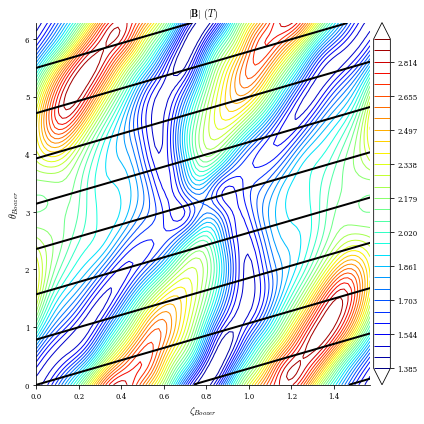

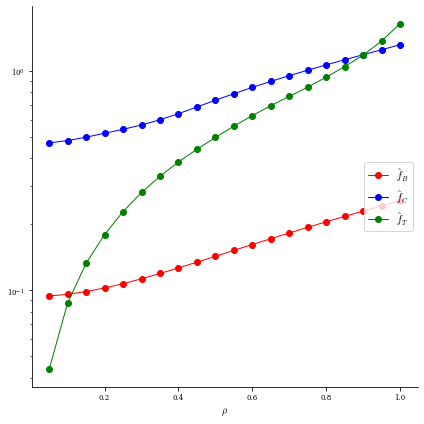

In [14]:
# eq = desc.io.load("../python/eq2optimized_equilibrium.h5")#desc.examples.get("ESTELL")
# plot_boozer_surface(eq_init, fieldlines=8)
fig, ax = plot_boozer_surface(eqfam[-1], fieldlines=8)
fig.savefig("figs/" + eq_name + "final_boozer_surface.png")
fig, ax = plot_qs_error(eqfam[-1])
fig.savefig("figs/" + eq_name + "final_qs_error.png")
    #fig.savefig("figs/" + eq_name + "rho=" + str(rho) + "final_boozer_surface.png")
    


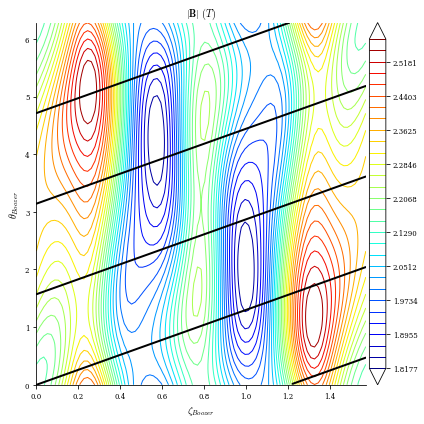

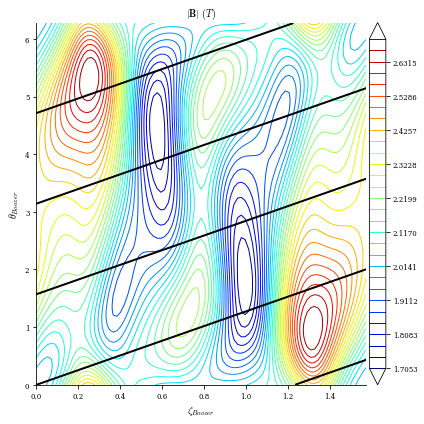

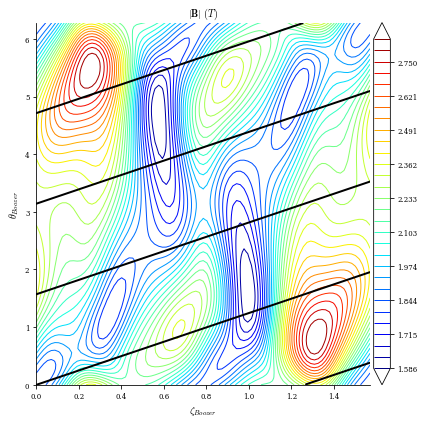

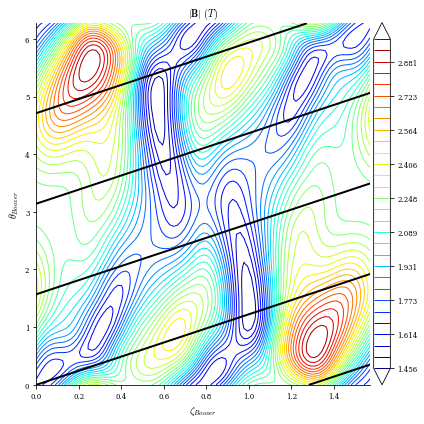

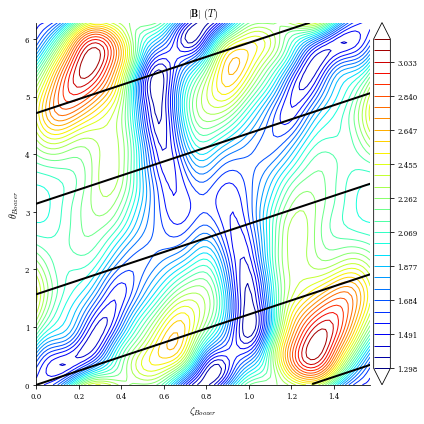

In [9]:

rhos = np.linspace(0.2, 1.0, 5)
for rho in rhos:
    fig, ax = plot_boozer_surface(eq_init, rho=rho, fieldlines=4)
    fig.savefig("figs/" + eq_name + "_initial_rho=" + str(rho) + "final_boozer_surface.png")
    

In [ ]:
from desc.plotting import plot_3d
from desc.grid import LinearGrid
grid = LinearGrid(
        rho=1.0,
        theta=np.linspace(0, 2 * np.pi, 100),
        zeta=np.linspace(0, 2 * np.pi, 100),
        axis=True,
    )
fig = plot_3d(eq_sc, "|F|", log=True, grid=grid)


In [ ]:
fig.write_image("figs/3dplot.png")